# iStar — super-resolve a paired Visium + H&E sample

iStar (Zhang et al., *Nature Biotechnology* 2024) imputes
gene expression at **near-single-cell** resolution by combining
the spot-level Visium counts you already have with the full
morphological detail in the underlying H&E image. The output
is a dense pixel-level grid (~8 µm/pixel by default) — much
finer than Visium's 55 µm spots — that you can cluster, cell-
type, or feed into downstream `ov.space` analysis just like
any other spatial AnnData.

**When to reach for iStar vs the spot-level backends**

| Goal | Use |
|---|---|
| Predict expression on a tissue section that has **only H&E** (no Visium) | `predict_expression(method='stpath' / 'stflow' / 'hest_fm')` |
| You already have **Visium + matched H&E** and want sub-spot resolution | `super_resolve(method='istar')` — this notebook |
| Same as above but only need spot-level predictions on the same slide | any of the spot-level methods will also work |

**Conceptually** iStar is a self-supervised refinement: it
trains a per-slide regression head from HIPT (Hierarchical
Image Pyramid Transformer, mahmoodlab) features → log1p
spot expression on *this slide's* paired ST data, then runs
that head on every sub-spot patch in the tissue mask.
Re-training on every slide means iStar adapts to staining /
tissue idiosyncrasies that out-of-the-box zero-shot models
cannot.

> **iStar is NOT a zero-shot model.** It cannot predict
> gene expression from H&E alone — the per-slide regression
> head trains on the paired Visium counts you pass as
> `adata`. Super-resolution then extrapolates that fit to
> sub-spot pixels on the *same* slide. If your slide has
> **only H&E** (no Visium), use
> `ov.space.histo.predict_expression(wsi, method='stpath',
> organ=...)` instead — STPath is a true zero-shot
> foundation model.

**Licence** — iStar's vendored source lives at
`omicverse.external.istar` and is GPL-3.0; commercial users
should contact the upstream authors (see
`omicverse/external/istar/NOTICE.md`).

## Environment

In [1]:
import warnings
warnings.filterwarnings('ignore')

import omicverse as ov
import lazyslide as zs
ov.utils.ov_plot_set()

print('omicverse', ov.__version__, '| lazyslide', zs.__version__)

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 | lazyslide 0.9.2


## Inputs iStar expects

iStar needs three things bound together: spot counts, spot
pixel coordinates in the H&E reference frame, and the full-
resolution H&E image itself. In the omicverse pipeline these
live in two objects:

- **`adata` — AnnData (Visium spot counts)**
  - `adata.X` (n_spots × n_genes) — raw counts
  - `adata.obsm['spatial']` (n_spots × 2) — *full-resolution
    pixel* (x, y) of each spot centre, in the same coordinate
    system as the H&E image
  - `adata.uns['spatial'][library_id]['scalefactors']` —
    Space Ranger's JSON, in particular
    `spot_diameter_fullres` (the spot diameter in
    full-resolution pixels) which iStar reads to set the
    physical scale
- **`wsi` — `wsidata.WSIData` (whole slide image)**
  - `wsi.reader.file` — the underlying `.tif` / `.svs` path
  - `wsi.properties.shape` — (height, width) in pixels at
    level 0
  - `wsi.properties.mpp` — microns per pixel (Visium FFPE
    images typically don't embed this; the omicverse loader
    derives it from `spot_diameter_fullres = 55 µm / mpp`
    and writes it back via `wsi.set_mpp`).

Both objects are returned together by the convenience loader
below; the next section shows how to assemble them yourself.

## How the WSI flows through LazySlide

iStar trains its own per-slide regression head, so it does
NOT need a pathology FM-embedding pass through LazySlide
the way the spot-level backends do. What it still uses
from LazySlide is the WSI container itself:

| omicverse call | LazySlide / wsidata under the hood |
|---|---|
| `ov.space.histo.open_wsi(path)` / `read_visium_with_image` | `wsidata.open_wsi(path)` → returns `WSIData` (a `SpatialData` subclass) wrapping the slide reader (openslide / tiffslide / bioformats) + a thumbnail |
| `wsi.read_region(x, y, w, h, level=…)` | the iStar wrapper uses this internally to extract patches around each Visium spot before handing them to HIPT |
| `ov.space.histo.super_resolve(adata, wsi=wsi, method='istar')` | omicverse-specific: stages inputs, trains the iStar head, returns the sub-spot AnnData |

For iStar specifically there is no `embed(model=…)` step —
HIPT feature extraction is part of the iStar pipeline and
uses iStar's own checkpoints, not the LazySlide model
registry. Tiling (`ov.space.histo.tile(…)`) is also
optional for the iStar path; the wrapper builds its own
spot-aligned patch grid from `adata.obsm['spatial']` +
`spot_diameter_fullres`.

## Model weights & cache layout

iStar wraps two pretrained HIPT vision-transformer
checkpoints and trains the regression head from scratch on
each slide.

| What | From | To | Size | Gated? |
|---|---|---|---|---|
| HIPT-256 (`vit256_small_dino.pth`) | mahmoodlab/HIPT GitHub LFS mirror | `$OV_HISTO_CACHE/istar_checkpoints/` (symlinked into `omicverse/external/istar/checkpoints/`) | ~672 MB | no |
| HIPT-4K (`vit4k_xs_dino.pth`) | mahmoodlab/HIPT GitHub LFS mirror | `$OV_HISTO_CACHE/istar_checkpoints/` (symlinked) | ~378 MB | no |
| iStar Python source | vendored in `omicverse/external/istar/` | shipped with omicverse | ~600 KB | — |
| per-slide super-resolution outputs | written by iStar | `$OV_HISTO_CACHE/istar_runs/{slide_stem}/cnts-super/{gene}.pickle` | ~10 MB / 50 genes | — |
| per-slide regression head weights | trained each run | `$OV_HISTO_CACHE/istar_runs/{slide_stem}/states/` | ~50 MB | — |

`$OV_HISTO_CACHE` defaults to `~/.cache/omicverse/histo`;
override with `OV_HISTO_CACHE=/some/path` (recommended on
HPC: point it at scratch).

Subsequent calls with the same `(slide, gene panel)` hit
the on-disk pickle cache and skip re-training entirely.

## Load the demo dataset

`ov.space.histo.load_breast()` downloads and caches the 10x Visium Breast Cancer Block A Section 1 sample (3,798 spots, 36,601 genes, 1.7 GB H&E) under `$OV_HISTO_CACHE/he_zoo/visium_breast` and returns the same `(adata, wsi)` pair you would build by hand on a real dataset.

In [2]:
adata, wsi = ov.space.histo.load_breast()
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'histo'
    obsm: 'spatial'

WSI: /scratch/users/steorra/cache/omicverse_histo/he_zoo/visium_breast/V1_Breast_Cancer_Block_A_Section_1_image.tif
Reader: tiffslide
Dimensions: 24240×24240 (h×w), 1 Pyramid
Pixel physical size: 0.3098911012751 MPP
SpatialData object
└── Images
      └── 'wsi_thumbnail': DataArray[cyx] (3, 2000, 2000)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images)
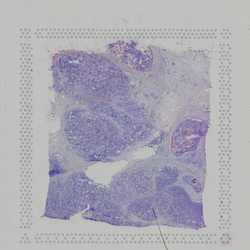

In [3]:
wsi

## Loading your own data

For your own Space Ranger output, use the lower-level helper
instead of `load_breast`:

```python
adata, wsi = ov.space.histo.read_visium_with_image(
    visium_path='/path/to/spaceranger/outs',  # contains filtered_feature_bc_matrix.h5 + spatial/
    image_path='/path/to/full_resolution_HE.tif',
    count_file='filtered_feature_bc_matrix.h5',
    library_id=None,           # auto-inferred from spatial/
)
```

Internally this delegates to scverse readers to get the spot
counts + spatial metadata, then `wsidata.open_wsi` to wrap
the H&E. It also auto-derives `wsi.properties.mpp` from
`spot_diameter_fullres` (Visium spots are 55 µm by design)
and writes the WSI path into `adata.uns['histo']['wsi_path']`
so the iStar backend can recover it later without you
re-passing it.

For non-Visium spatial transcriptomics (Stereo-seq, Slide-seq,
Visium HD, …) you can build `(adata, wsi)` manually: any
AnnData with `.X`, `.obsm['spatial']`, and an
`uns['spatial'][lib]['scalefactors']['spot_diameter_fullres']`
entry works as the `adata` argument; the `wsi` is just
whatever `wsidata.open_wsi('path.tif')` returns. The
spatial coordinates must be in the same pixel frame as the
H&E (Space Ranger guarantees this; for other platforms you
may need an affine registration step first).

## Run iStar end-to-end

One call performs the entire pipeline:

1. **stage inputs** into the on-disk format iStar's scripts
   expect (`cnts.tsv`, `locs-raw.tsv`, `he-raw.jpg`,
   `pixel-size-raw.txt`, `radius-raw.txt`),
2. **rescale** image + locations to `pixel_size` µm/pixel,
3. **extract HIPT features** (downloads the mahmoodlab/HIPT
   `vit256_small_dino.pth` + `vit4k_xs_dino.pth` checkpoints
   into `$OV_HISTO_CACHE/istar_checkpoints/` on first use),
4. **detect tissue mask** from those features,
5. **select genes** to impute (HVGs by default, or whatever
   you pass via `genes=`),
6. **train** the per-slide regression head for `epochs`
   iterations,
7. **impute** sub-spot expression and **read it back** as an
   AnnData where rows are in-tissue pixels and columns are
   genes.

Subsequent calls with the same `(adata, wsi)` and the same
gene panel hit the on-disk pickle cache and return in seconds.

### Key parameters

- `pixel_size=0.5` — output grid resolution in µm/pixel
  (default `0.5`, matches the paper; halve for finer grids,
  double for coarser/faster).
- `n_top_genes=50` — number of highly-variable genes to
  impute when `genes=` is not given. The demo uses 50 to
  keep the per-slide training tractable; the paper uses
  `n_top_genes=1000`.
- `genes=['EPCAM', 'ERBB2', …]` — explicit gene panel; takes
  precedence over `n_top_genes` and is written to
  `gene-names.txt` for iStar.
- `epochs=80` — training iterations for the per-slide head.
  The paper default is `400`; `80` gives a quick demo with
  already-reasonable quality. Time scales ~linearly with
  `epochs`.
- `device='cuda'` — defaults to CUDA when available, else CPU.
- `cache_dir=None` — override the default
  `$OV_HISTO_CACHE/istar_runs/<slide_stem>/` working
  directory.
- `hipt256_path`, `hipt4k_path` — explicit local paths to the
  HIPT-256 / HIPT-4K weight files. When given, the
  mahmoodlab/HIPT LFS download is skipped (useful when the
  host doesn't have GitHub network access or when the HIPT
  checkpoints have been pre-staged elsewhere).

### Air-gapped run (HIPT checkpoints already staged)

```python
pred = ov.space.histo.super_resolve(
    adata, wsi=wsi, method='istar',
    pixel_size=0.5, n_top_genes=50, epochs=80,
    hipt256_path='/scratch/weights/HIPT/vit256_small_dino.pth',
    hipt4k_path='/scratch/weights/HIPT/vit4k_xs_dino.pth',
    cache_dir='/scratch/omicverse_histo',
)
```

In [4]:
pred = ov.space.histo.super_resolve(
    adata,
    wsi=wsi,
    method='istar',
    pixel_size=0.5,    # 0.5 µm / pixel ⇒ ~8 µm sub-spot grid
    n_top_genes=50,
    epochs=80,
)
pred

AnnData object with n_obs × n_vars = 392830 × 50
    obs: 'x', 'y'
    uns: 'histo'
    obsm: 'spatial'

## Reading the output

`pred` is an `AnnData` whose rows are **in-tissue pixels** on
the super-resolution grid and whose columns are the imputed
genes:

- `pred.X` (n_pixels × n_genes) — log1p imputed expression,
  `float32`
- `pred.obs` carries pixel coordinates as `x` / `y` columns,
  with row names of the form `'px_<y>_<x>'`
- `pred.var_names` — gene symbols (same order as
  `gene-names.txt`)
- `pred.obsm['spatial']` (n_pixels × 2) — same `(x, y)` pixel
  positions, ready for any spatial plotter
- `pred.uns['histo']` — run metadata (`method`, `pixel_size`,
  `factor`, `work_dir`).

Compared with the input Visium AnnData (3,798 spots) the
output covers far more locations (here 392,830 sub-spot
pixels inside the tissue mask), which is what makes
cell-type pixel annotation and high-resolution clustering
possible downstream.

In [5]:
print('input  Visium :', adata.shape)
print('output sub-spot:', pred.shape)
print('coords range  :', pred.obsm['spatial'].min(0), '→',
                         pred.obsm['spatial'].max(0))
print('metadata      :', pred.uns['histo'])

input  Visium : (3798, 36601)
output sub-spot: (392830, 50)
coords range  : [159. 137.] → [798. 866.]
metadata      : {'method': 'istar', 'pixel_size': 0.5, 'factor': 8, 'work_dir': '/scratch/users/steorra/cache/omicverse_histo/istar_runs/V1_Breast_Cancer_Block_A_Section_1_image', 'cache_hit': True}


## Visualise sub-spot expression

Because `pred` carries pixel coordinates in `obsm['spatial']`, any spatial plotter (`ov.pl.embedding`, `ov.pl.spatial`, `zs.pl.tiles`) renders it without extra bookkeeping. The small dot size (`s=1`) is appropriate because the grid is very dense.

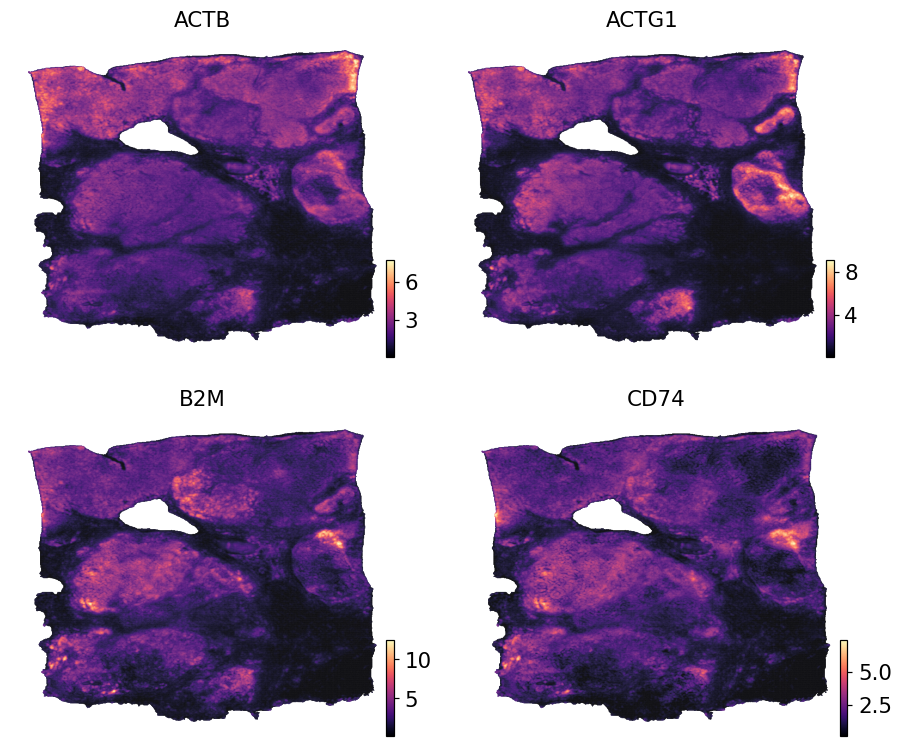

In [6]:
ov.pl.embedding(pred, basis='spatial',
                color=list(pred.var_names[:4]),
                cmap='magma', s=1, ncols=2, frameon=False)

### Real Visium counts for the same genes

Render the same four imputed genes from the paired Visium reference so the sub-spot imputation can be eyeballed against the spot-level ground truth. The reference is log1p-normalised to match iStar's output scale.


🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,798 cells × 36,601 genes
   ✓ Runtime: 0.05s


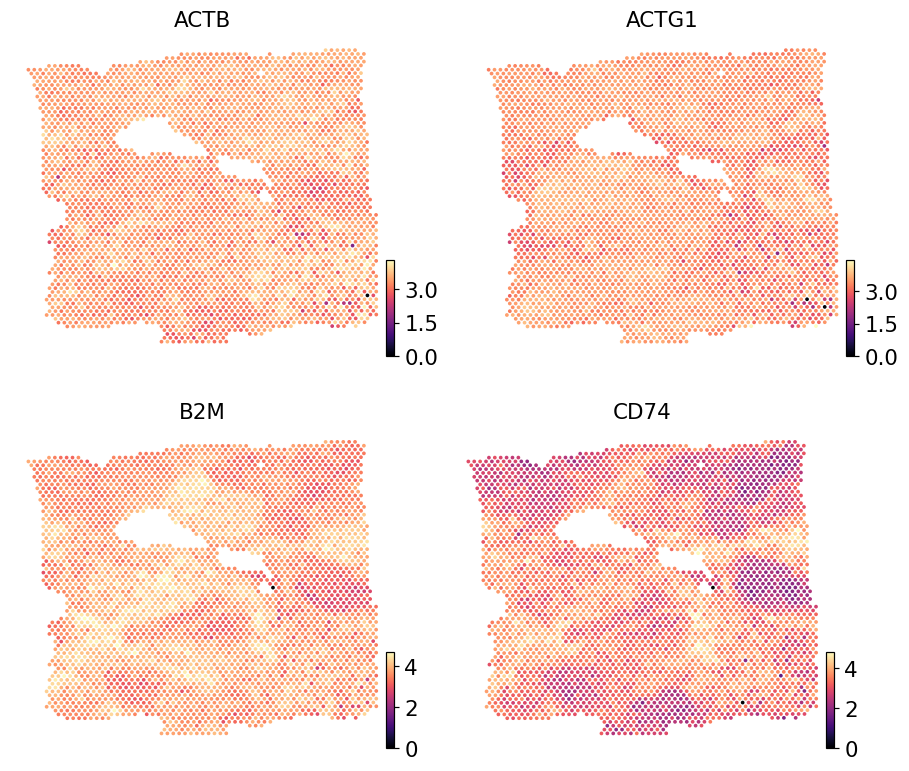

In [7]:
ref = adata.copy()
ov.pp.normalize_total(ref, target_sum=1e4)
ov.pp.log1p(ref)
ov.pl.embedding(ref, basis='spatial',
                color=list(pred.var_names[:4]),
                cmap='magma', s=24, ncols=2, frameon=False)

## Where to go next

The output AnnData feeds the rest of `ov.space` directly:

```python
# spatial domain detection on the sub-spot grid
ov.space.pySTAGATE(pred, n_domains=8, radius=20)

# spatially-variable genes
pred = ov.space.svg(pred, mode='prost', n_svgs=200)

# marker enrichment for cell-type calling
ov.single.cosg(pred, groupby='STAGATE_domain')
```

For a head-to-head comparison with the spot-level backends
on the same H&E, see the sibling tutorials
([STPath](t_histo_stpath.ipynb),
[STFlow](t_histo_stflow.ipynb),
[HEST-FM](t_histo_hest_fm.ipynb)).